In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# L17

# Part 1

## Data

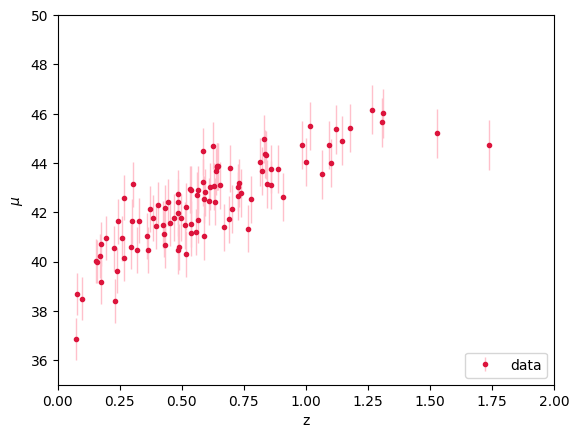

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.', c='crimson', ecolor='pink', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [3]:
X,y,dy = z_sample, mu_sample, dmu
X=X[:, np.newaxis]

## Linear

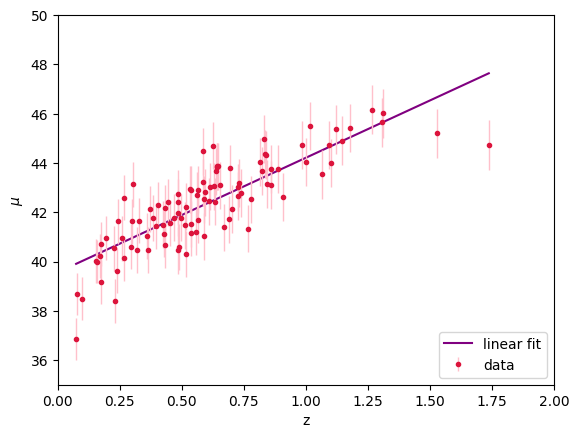

In [4]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=1.0)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

#print(theta0, theta1)
X_plot=np.array([np.min(X),np.max(X)])
X_plot=X_plot[:, np.newaxis]
y_pred=lin_reg.predict(X_plot)

plt.plot(X_plot,y_pred, c='purple', label='linear fit')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.', ecolor='pink',color='crimson',lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

## Polynomial

C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


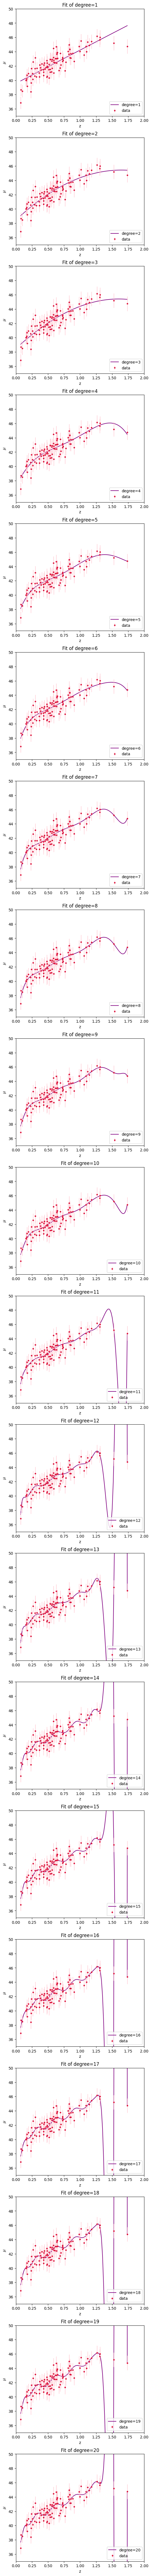

In [5]:
from astroML.linear_model import PolynomialRegression

fig=plt.figure(figsize=[6,120])

degrees=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
for i in range(len(degrees)):
    degree=degrees[i]
    ax=fig.add_subplot(len(degrees),1,degree)
    
    model = PolynomialRegression(degree)
    model.fit(X, y)

    n_constraints = degree + 1
    
    X_plot=np.linspace(np.min(X),np.max(X),100)
    X_plot=X_plot[:, np.newaxis]
    y_pred = model.predict(X_plot)
    
    ax.plot(X_plot,y_pred, c='purple', label='degree='+str(degree))
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.', ecolor='pink',color='crimson',lw=1,label='data')
    ax.set_xlabel("z")
    ax.set_ylabel(r"$\mu$")
    ax.legend(loc='lower right')
    ax.set_xlim(0,2)
    ax.set_ylim(35,50);
    ax.set_title("Fit of degree="+str(degree))

The third degree polynomial seems to fit quite well!

## Cross validation

In [6]:
from sklearn.model_selection import train_test_split

Xtrain, Xcv, ydy_train, ydy_validation = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state=42)
ytrain,dytrain = ydy_train.T
ycv,dycv = ydy_validation.T

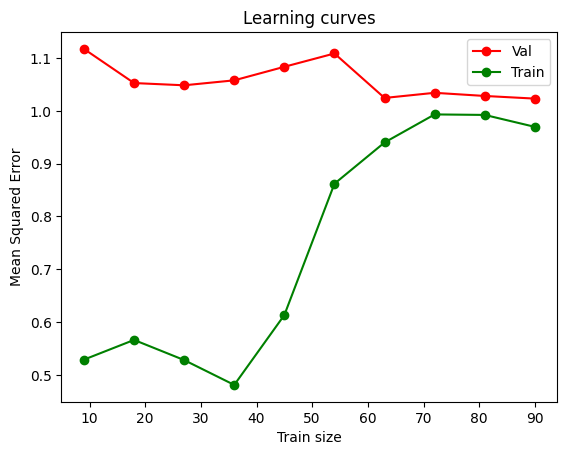

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

lin_reg = LinearRegression()
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(lin_reg, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)


plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

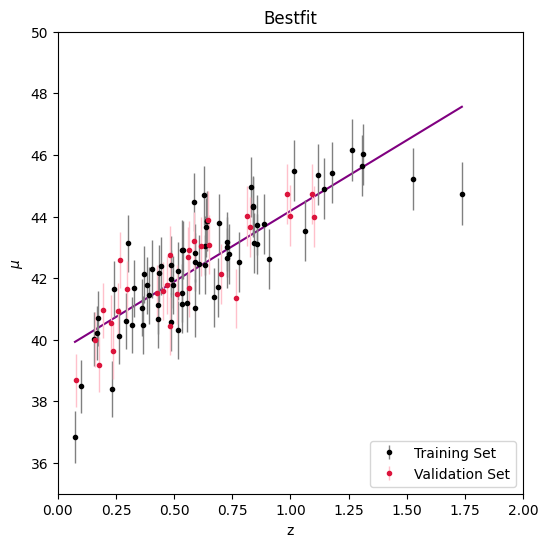

In [8]:
fig = plt.figure(figsize=(6, 6))
model = LinearRegression()
model.fit(Xtrain, ytrain)
    
X_plot=np.linspace(np.min(X),np.max(X),100)
X_plot=X_plot[:, np.newaxis]
y_pred = model.predict(X_plot)
    
plt.plot(X_plot,y_pred, c='purple')
plt.errorbar(Xtrain, ytrain, dytrain, fmt='.', ecolor='gray',color='k',lw=1,label='Training Set')
plt.errorbar(Xcv, ycv, dycv, fmt='.', ecolor='pink',color='crimson',lw=1,label='Validation Set')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);
plt.title("Bestfit");

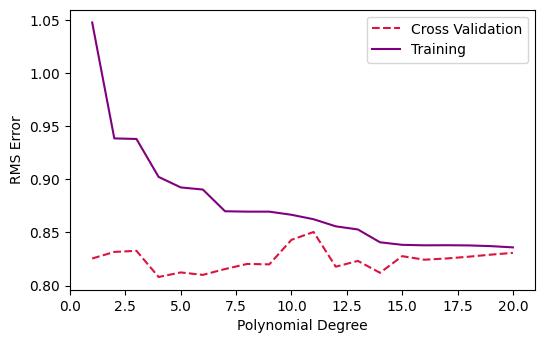

In [9]:
fig = plt.figure(figsize=(6, 8))

degrees=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
training_err=np.zeros(len(degrees))
crossval_err=np.zeros(len(degrees))
for i in range(len(degrees)):
    d=degrees[i]
    model = PolynomialRegression(d)
    model.fit(Xtrain, ytrain)
    training_err[i] =np.sqrt( np.sum(( ytrain - model.predict(Xtrain) )**2) / len(Xtrain) )
    crossval_err[i] =np.sqrt( np.sum(( ycv - model.predict(Xcv) )**2) / len(Xcv) )
    crossval_err[i] = np.sqrt(np.sum((model.predict(Xcv) - ycv) ** 2) / len(ycv))

ax = fig.add_subplot(211)
ax.plot(degrees, crossval_err, '--', c="crimson", label='Cross Validation')
ax.plot(degrees, training_err, '-', c="purple", label='Training')

ax.set_xlim(0, 21)

ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('RMS Error')
ax.legend(loc="upper right");

In [10]:
best=degrees[np.argmin(crossval_err)]
print("Bestfit Polynomial degree", best)

Bestfit Polynomial degree 4


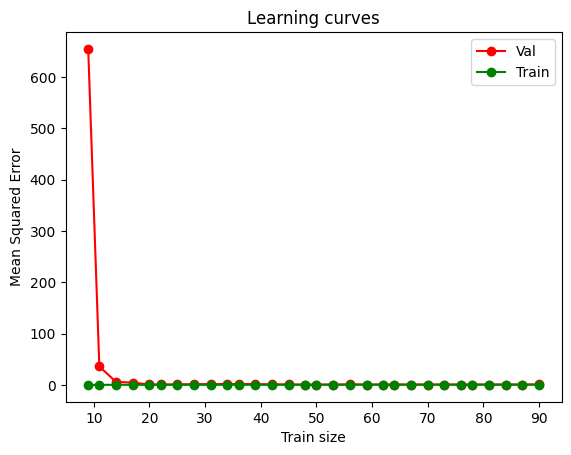

In [11]:
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

pol_reg = model = PolynomialRegression(best)
train_sizes, train_scores_polreg, test_scores_polreg = \
    learning_curve(pol_reg, Xscaled, y, train_sizes=np.linspace(0.1, 1, 30), \
    scoring="neg_mean_squared_error", cv=10)

plt.plot(train_sizes, -test_scores_polreg.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_polreg.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

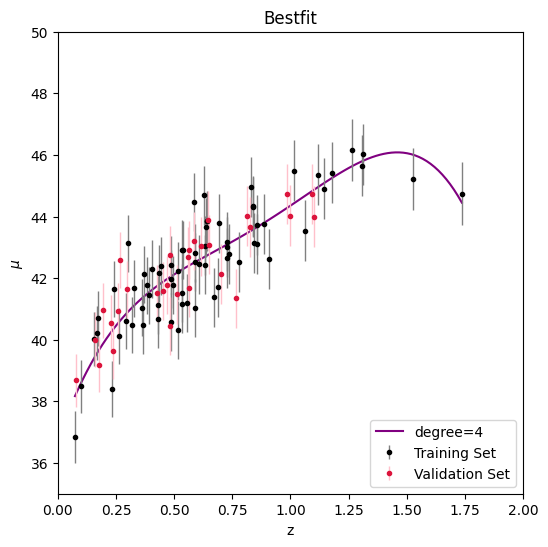

In [12]:
fig = plt.figure(figsize=(6, 6))
model = PolynomialRegression(best)
model.fit(Xtrain, ytrain)
    
X_plot=np.linspace(np.min(X),np.max(X),100)
X_plot=X_plot[:, np.newaxis]
y_pred = model.predict(X_plot)
    
plt.plot(X_plot,y_pred, c='purple', label='degree='+str(best))
plt.errorbar(Xtrain, ytrain, dytrain, fmt='.', ecolor='gray',color='k',lw=1,label='Training Set')
plt.errorbar(Xcv, ycv, dycv, fmt='.', ecolor='pink',color='crimson',lw=1,label='Validation Set')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);
plt.title("Bestfit");

# L18

# Part 2

## GPR

In [13]:
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.optimize import fmin_cobyla

In [14]:
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

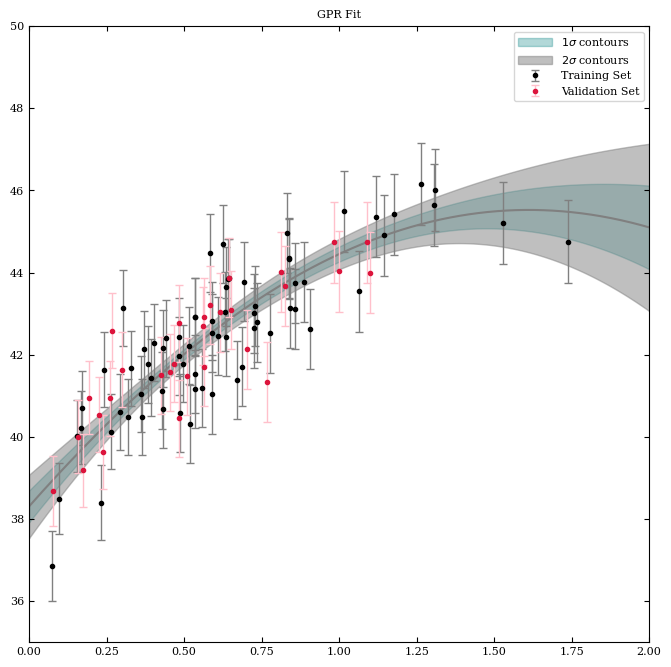

In [40]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) #automatically doing cv to find the best bandwidth
gp3 = GaussianProcessRegressor(kernel=kernel,
                               alpha=(dytrain)**2,
                               random_state=0)
gp3.fit(Xtrain, ytrain)
Xv=np.sort(X)
x=np.linspace(0,2,1000)
x=x[:, np.newaxis]
f3, f3_err = gp3.predict(x, 
                         return_std=True)

fig=plt.figure(figsize=[8,8])
ax = fig.add_subplot(111)
x=x[:,0]

ax.plot(x, f3, color='gray')
ax.fill_between(x, f3 - f3_err, f3 + f3_err, 
                color='teal', alpha=0.3, label=r'$1\sigma$'+' contours')
ax.fill_between(x, f3 - 2 * f3_err, f3 + 2 * f3_err, 
                color='gray', alpha=0.5, label=r'$2\sigma$'+' contours')

ax.errorbar(Xtrain, ytrain, dytrain, fmt='.', ecolor='gray',color='k',lw=1,label='Training Set')
ax.errorbar(Xcv, ycv, dycv, fmt='.', ecolor='pink',color='crimson',lw=1,label='Validation Set')
ax.set_title('GPR Fit')
ax.set_xlim(0,2)
ax.set_ylim(35,50);

plt.legend();

In [48]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

bwrange = np.linspace(0.01,100, 30)
K = 10
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) 
grid.fit(X) 
h_opt = grid.best_params_['bandwidth']
print(h_opt)

3.4579310344827583


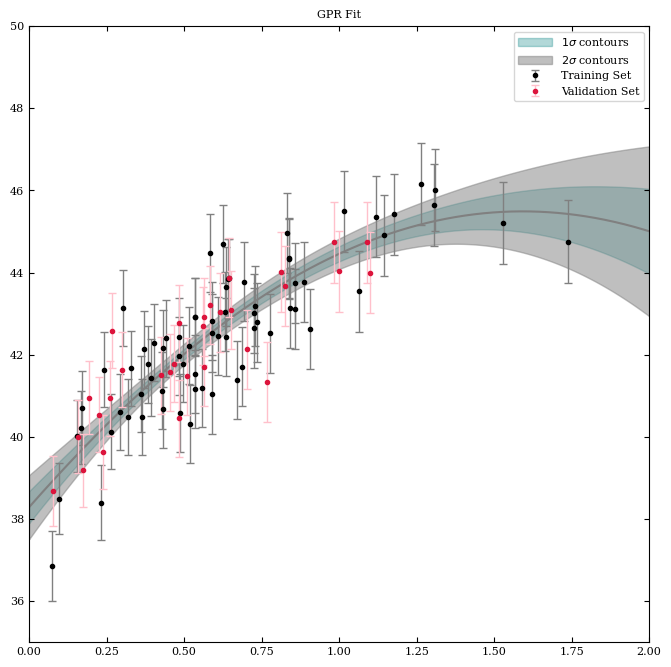

In [49]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(h_opt, "fixed")
gp3 = GaussianProcessRegressor(kernel=kernel,
                               alpha=(dytrain)**2,
                               random_state=0)
gp3.fit(Xtrain, ytrain)
Xv=np.sort(X)
x=np.linspace(0,2,1000)
x=x[:, np.newaxis]
f3, f3_err = gp3.predict(x, 
                         return_std=True)

fig=plt.figure(figsize=[8,8])
ax = fig.add_subplot(111)
x=x[:,0]

ax.plot(x, f3, color='gray')
ax.fill_between(x, f3 - f3_err, f3 + f3_err, 
                color='teal', alpha=0.3, label=r'$1\sigma$'+' contours')
ax.fill_between(x, f3 - 2 * f3_err, f3 + 2 * f3_err, 
                color='gray', alpha=0.5, label=r'$2\sigma$'+' contours')

ax.errorbar(Xtrain, ytrain, dytrain, fmt='.', ecolor='gray',color='k',lw=1,label='Training Set')
ax.errorbar(Xcv, ycv, dycv, fmt='.', ecolor='pink',color='crimson',lw=1,label='Validation Set')
ax.set_title('GPR Fit')
ax.set_xlim(0,2)
ax.set_ylim(35,50);

plt.legend();

## Cloning Data

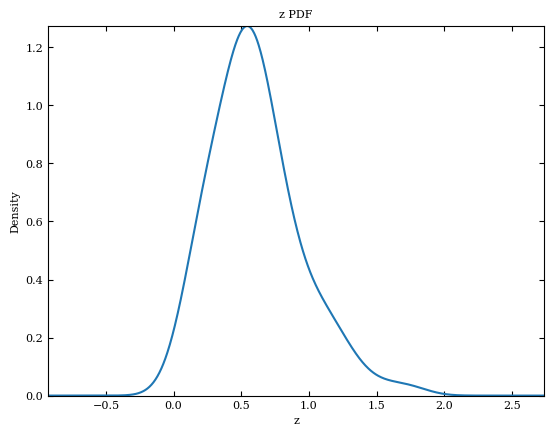

In [54]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

z_vals = np.array(z_sample).reshape(-1, 1) 

bwrange = np.linspace(0.01,1, 30)
K = 10
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) 
grid.fit(z_vals) 
h_opt = grid.best_params_['bandwidth']

kde = KernelDensity(kernel='gaussian', bandwidth=h_opt).fit(z_vals)

z_plot = np.linspace(z_vals.min() - 1, z_vals.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_plot)
dens = np.exp(log_dens)

plt.plot(z_plot[:, 0], dens)
plt.xlabel('z')
plt.ylabel('Density')
plt.title("z PDF");

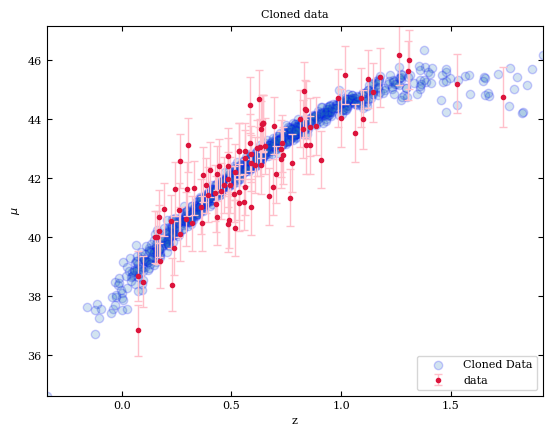

In [55]:
N = 1000
new_z_samples = kde.sample(N)

mu_gpr=[]
for z in np.squeeze(new_z_samples):    
    mu_fit, sigma = gp3.predict([[z]], 
                           return_std=True)
    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma))
    
plt.xlabel("z")
plt.ylabel(r"$\mu$")

plt.errorbar(z_sample, mu_sample, dmu, fmt='.', c='crimson', ecolor='pink', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")

plt.scatter(new_z_samples,mu_gpr,alpha=0.2, label='Cloned Data')
plt.title("Cloned data")
plt.legend(loc='lower right');

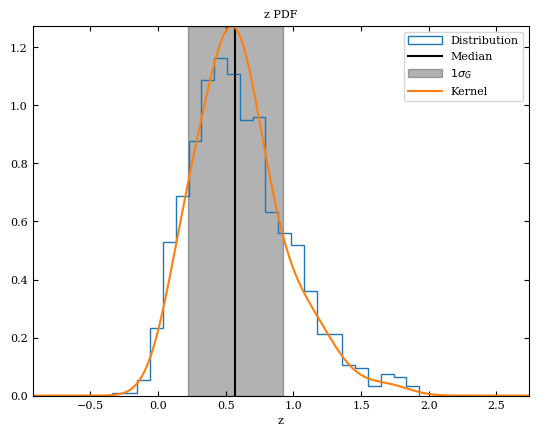

In [88]:
import astropy
from astroML import stats as astroMLstats
astropy.visualization.hist(new_z_samples, bins="freedman", histtype="step",density=True, label='Distribution')

medX=np.median(new_z_samples)
sigmaGX=astroMLstats.sigmaG(new_z_samples)

plt.axvline(medX, color='k', label='Median')
plt.axvspan(medX-sigmaGX,medX+sigmaGX, color='k', alpha=0.3, label=r'$1\sigma_G$')

plt.plot(z_plot[:, 0], dens, label='Kernel')
plt.xlabel("z")
plt.title("z PDF")
plt.legend();

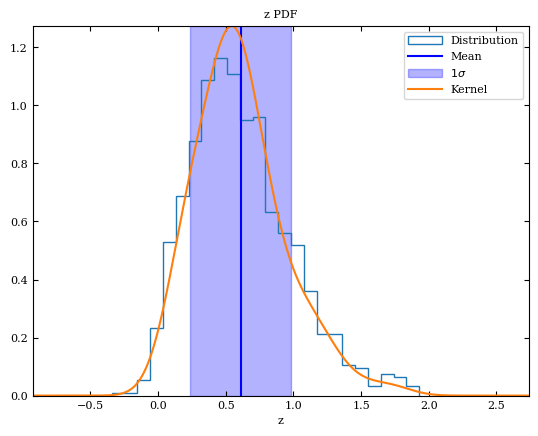

In [89]:
astropy.visualization.hist(new_z_samples, bins="freedman", histtype="step",density=True, label='Distribution')

meanX=np.mean(new_z_samples)
stdX=np.std(new_z_samples)

plt.axvline(meanX, color='b', label='Mean')
plt.axvspan(meanX-stdX,meanX+stdX, color='b', alpha=0.3,label=r'$1\sigma$')

plt.plot(z_plot[:, 0], dens, label='Kernel')
plt.xlabel("z")
plt.title("z PDF")
plt.legend();

In [90]:
print("The Median is", medX)
print("The Mean is", meanX)

The Median is 0.5699906896355795
The Mean is 0.611387454570792


# Part 3

## Cosmology

In [18]:
from astropy.cosmology import LambdaCDM

def generativemodel(z, H0, Om=1):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om)
    return cosmo_tmp.distmod(z).value

## Nested Sampling: Real Universe

In [122]:
def Logprior(u):
    u[1]=u[1]*70+30
    u[0]=u[0]*0.99+0.01
    return u

def LogLikelihood(theta):
    Om,H0 = theta    
    if Om<0:
        return -np.inf
    else:
        mu_model = generativemodel(z_sample, H0, Om)
    return np.sum(scipy.stats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))

def LogPosterior(theta):
    return LogLikelihood(theta) + Logprior(theta)

In [123]:
import dynesty
ndim=2

In [124]:
sampler = dynesty.NestedSampler(LogLikelihood, Logprior, ndim,nlive=1000)
sampler.run_nested()
sresults = sampler.results

2749it [08:06,  5.65it/s, +1000 | bound: 0 | nc: 1 | ncall: 17757 | eff(%): 22.373 | loglstar:   -inf < -132.813 <    inf | logz: -135.279 +/-  0.020 | dlogz:  0.001 >  1.009]


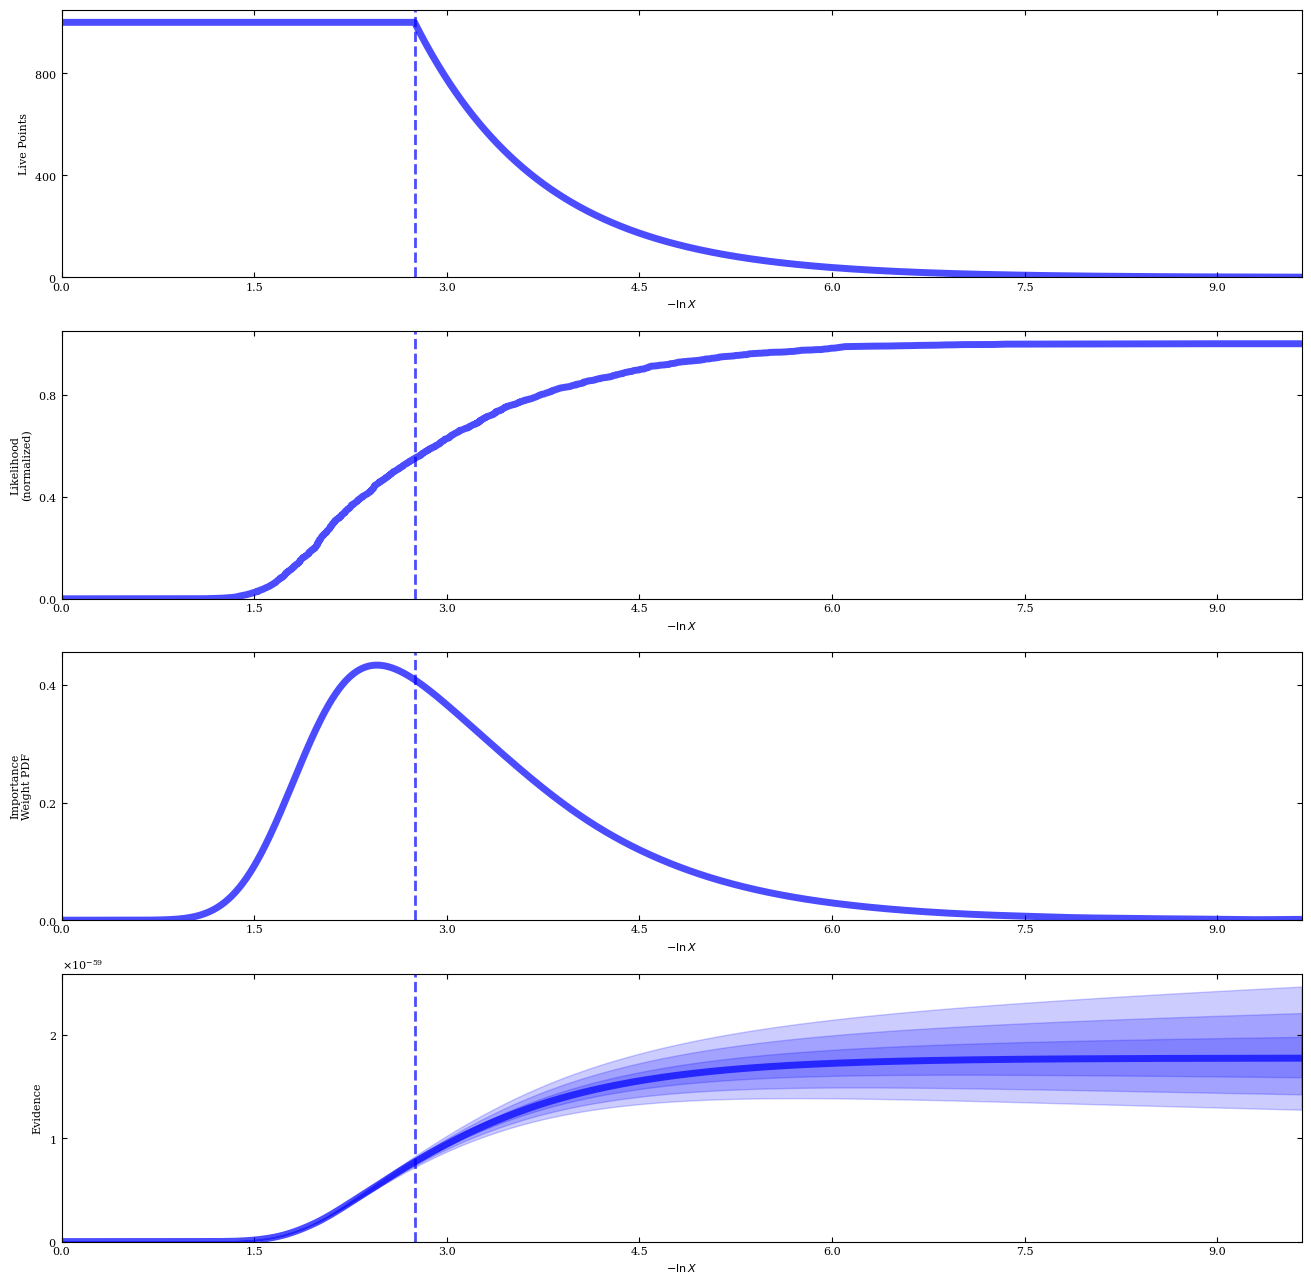

In [125]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

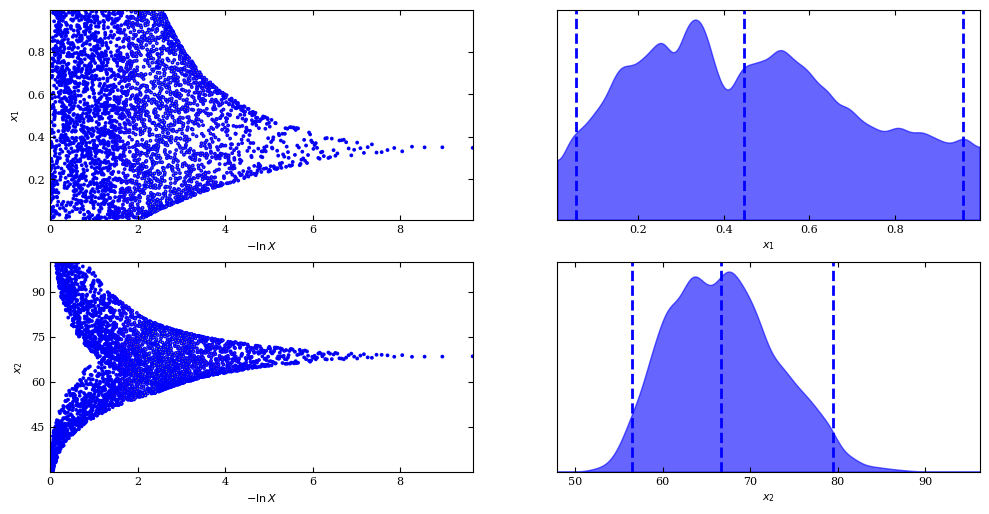

In [126]:
tfig, taxes = dyplot.traceplot(sresults)

In [127]:
from dynesty import utils as dyfunc

samples = sresults.samples
weights = np.exp(sresults.logwt - sresults.logz[-1])

evidence = sresults.logz[-1]
print("Bayesian evidence", np.exp(evidence))

quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

Bayesian evidence 1.7738370318091815e-59
68% parameter credible regions are:
 [[0.1918770711459623, 0.7582821686549065], [60.58898799013148, 73.48251113777624]]

Mean and covariance of parameters are: [ 0.46581667 66.92530808]
[[ 0.06440811 -1.35963983]
 [-1.35963983 37.93463017]]


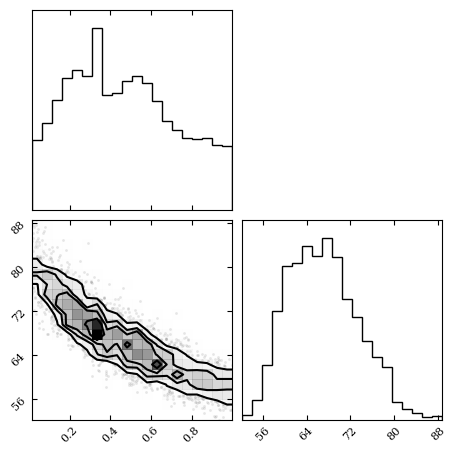

In [128]:
import corner
samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal);

In [132]:
labels = ['Omega_m','H_0']

quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

Omega_m   0.44737508440973556 +0.470479651660006 -0.3579498515129519
H_0   66.61994300764118 +11.218479687556979 -8.909679384025814


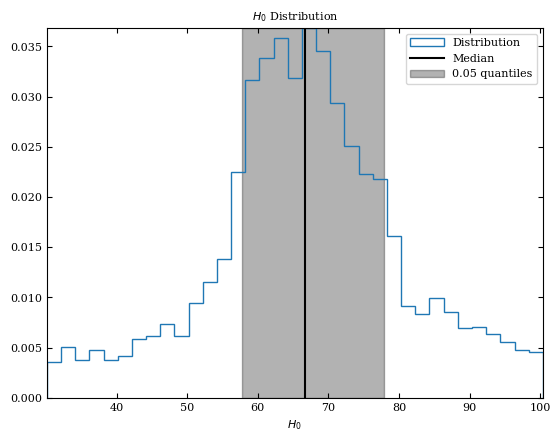

In [139]:
astropy.visualization.hist(samples[:,1], bins="freedman", histtype="step",density=True, label='Distribution');
low,med,up=quantiles[1]
plt.axvline(med, color='k', label='Median')
plt.axvspan(med-(med-low),med+(up-med), color='k', alpha=0.3,label="0.05 quantiles")
plt.title(r"$H_0$ Distribution")
plt.xlabel(r"$H_0$")
plt.legend();

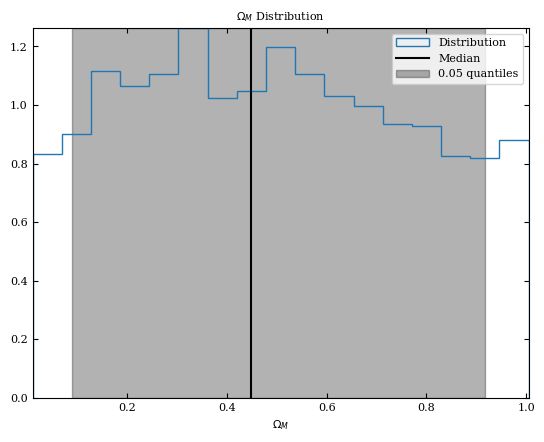

In [138]:
astropy.visualization.hist(samples[:,0], bins="freedman", histtype="step",density=True, label='Distribution');
low,med,up=quantiles[0]
plt.axvline(med, color='k', label='Median')
plt.axvspan(med-(med-low),med+(up-med), color='k', alpha=0.3,label="0.05 quantiles")
plt.title(r"$\Omega_M$ Distribution")
plt.xlabel(r"$\Omega_M$")
plt.legend();

## Nested Sampling: No Dark Energy

In [94]:
def Logprior(u):
    u[1]=u[1]*70+30
    u[0]=1
    return u

def LogLikelihood(theta):
    Om,H0 = theta    
    mu_model = generativemodel(z_sample, H0, Om)
    return np.sum(scipy.stats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))
                   
def LogPosterior(theta):
    return LogLikelihood(theta) + Logprior(theta)

In [95]:
import dynesty
ndim=2

In [96]:
sampler = dynesty.NestedSampler(LogLikelihood, Logprior, ndim, nlive=1000)
sampler.run_nested()
sresults2 = sampler.results

2821it [08:57,  5.25it/s, +1000 | bound: 0 | nc: 1 | ncall: 17410 | eff(%): 23.285 | loglstar:   -inf < -133.530 <    inf | logz: -135.964 +/-    nan | dlogz:  0.001 >  1.009]


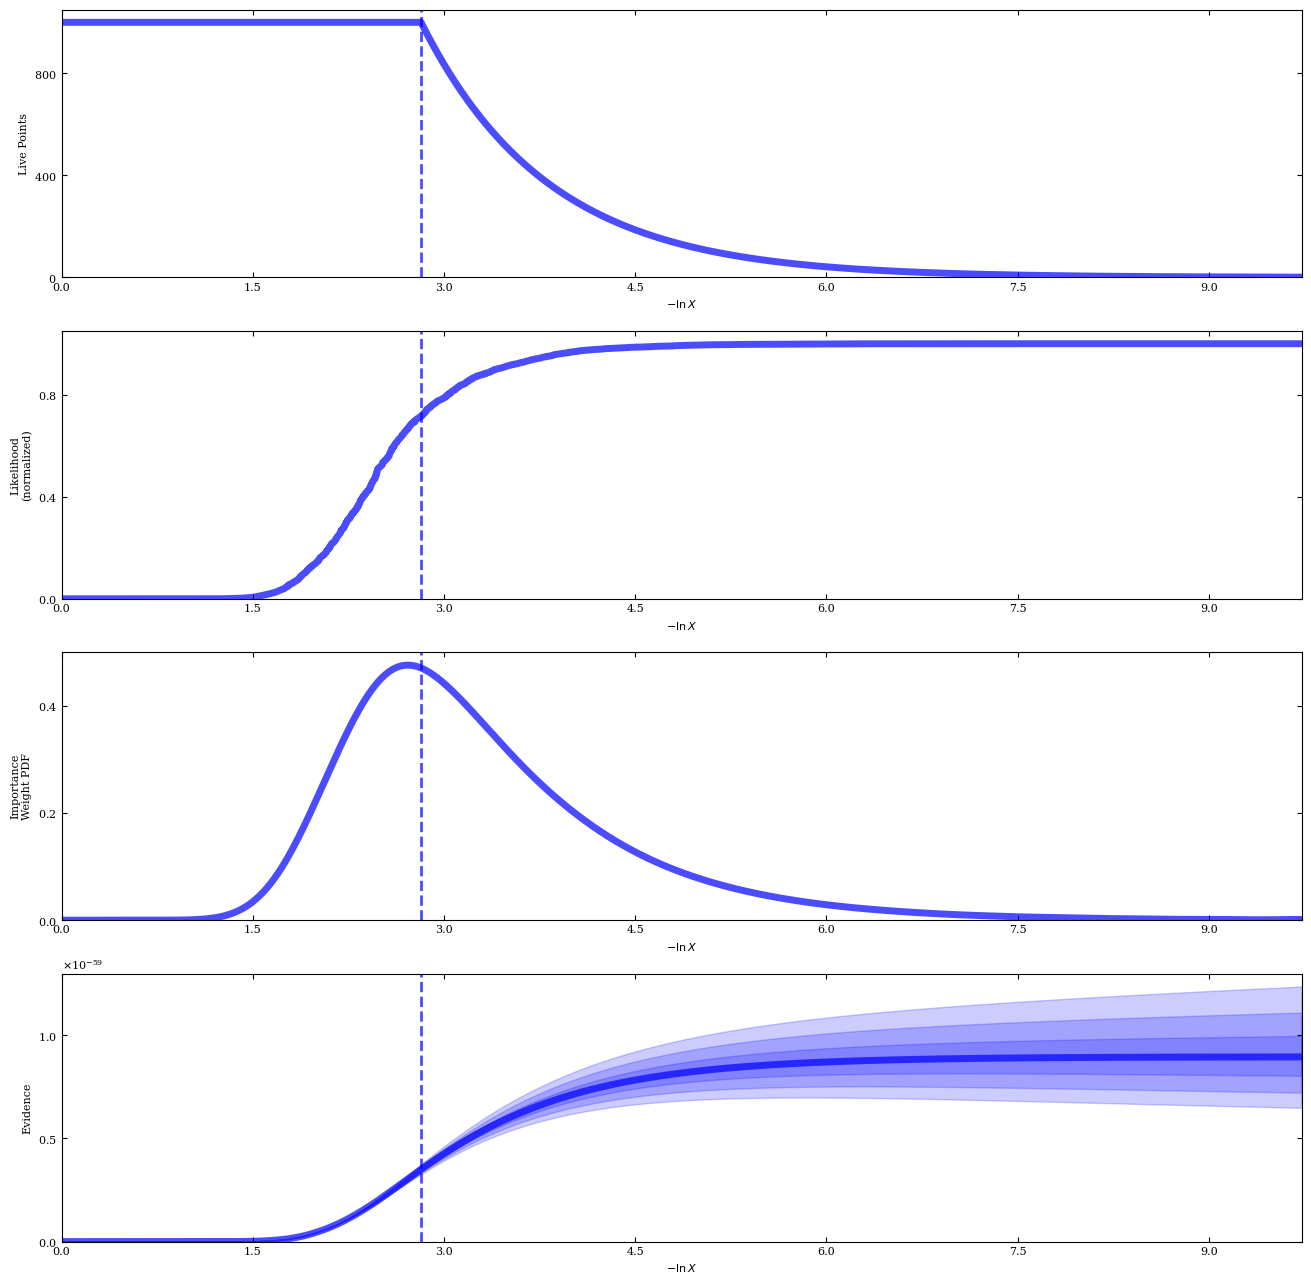

In [97]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults2)

C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dynesty\plotting.py:706: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min(x), max(x)])
C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dynesty\plotting.py:749: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(span[i])


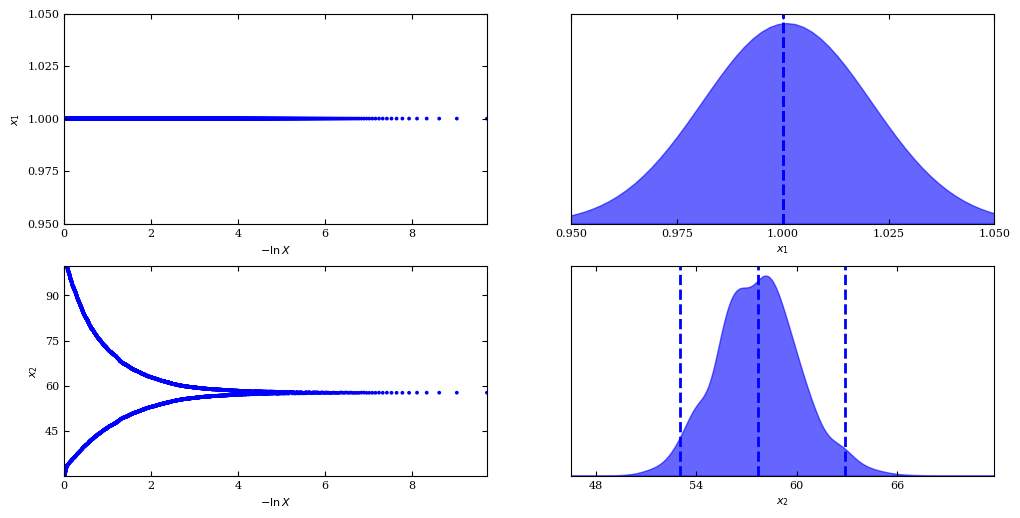

In [98]:
tfig, taxes = dyplot.traceplot(sresults2)

In [104]:
from dynesty import utils as dyfunc

samples = sresults2.samples  
weights = np.exp(sresults2.logwt - sresults2.logz[-1]) 

evidence2 = sresults2.logz[-1]
print("Bayesian evidence", np.exp(evidence2))

quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

Bayesian evidence 8.944232826966078e-60
68% parameter credible regions are:
 [[1.0, 1.0], [55.33033188820769, 60.02495321191047]]

Mean and covariance of parameters are: [ 1.         57.66993449]
[[1.23324765e-30 2.06354608e-30]
 [2.05433887e-30 6.16084485e+00]]


In [119]:
labels = ['Omega_m','H_0']

quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

Omega_m   1.0 +0.0 -0.0
H_0   57.65983129851125 +4.287365003819367 -4.0445290218217025


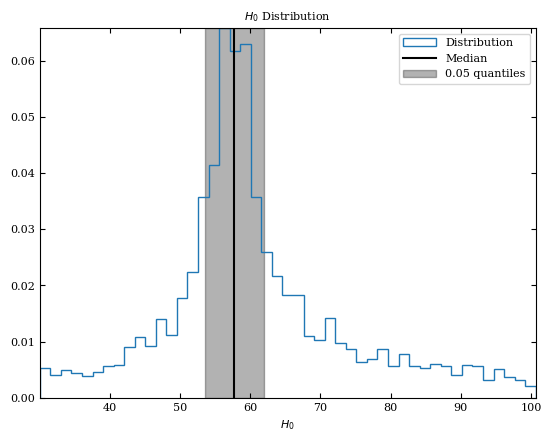

In [120]:
astropy.visualization.hist(samples[:,1], bins="freedman", histtype="step",density=True, label='Distribution');
plt.axvline(med, color='k', label='Median')
plt.axvspan(med-(med-low),med+(up-med), color='k', alpha=0.3,label="0.05 quantiles")
plt.title(r"$H_0$ Distribution")
plt.xlabel(r"$H_0$")
plt.legend();

In [106]:
bayes_factor=np.exp(evidence)/np.exp(evidence2)
if bayes_factor > 100: print(bayes_factor,'Decisive')
elif bayes_factor > 30: print(bayes_factor,'Very strong')
elif bayes_factor > 10: print(bayes_factor,'Strong')
elif bayes_factor > 3: print(bayes_factor,'Substantial')
elif bayes_factor > 1: print(bayes_factor,'Barely worth mentioning')
else: print('Negative')

1.9379762755337104 Barely worth mentioning
